# 3-way comparison — EDGAR vs SINDy vs STENCIL-NET (unforced Burgers)

Rudimentary loader + explorer for the finished sweeps. Two things it gives you:

1. **`bench` / `edgar` / `all_results` DataFrames** — forecast MSE, persistence floor, skill,
   per (method, noise level, rollout horizon, sample).
2. **`*_predict(...)` helpers** — regenerate predictions and targets for any single cell,
   plus `to_canvas(...)` to put any method's predictions on the same `(n_sensors, T)` grid.

### Read before comparing numbers across methods

* All three are scored on **noisy** targets seeded from **noisy** states (`u_noisy`), so noise
  levels are on the same footing. The bench numbers come from `rescore_noisy.json`
  (`horizons_noisy_scored`), *not* the older clean-scored `horizons` in the per-run JSONs.
* **The protocols are still not identical.** SINDy / STENCIL-NET learn a continuous RHS stepped
  by RK3 from *every* column with `h` steps ahead, seeded from one state. EDGAR learns a discrete
  AR map with `m = 5` lags, restarted per 200-column block, dropping the first `m-1` columns of
  each block. Same field, same train/test blocks, same targets — but the start sets differ at the
  edges. **Prefer `skill` (1 - mse/persistence) over raw MSE** when comparing methods, since each
  method's persistence floor is computed over its own start set.
* At `nl=0.1` the noise floor eats most of the dynamic range (headroom over persistence is only
  ~2.1x), so that arm measures noise robustness, not equation quality.
* **`validate` is not a like-for-like generalisation split.** For EDGAR it is unseen viscosities.
  STENCIL-NET trains one net per sample and SINDy one fit per sample, so their "validate"
  samples are in-sample refits. Only the `discover` rows compare cleanly.

Regenerating SINDy predictions imports `bench/sindy/runner.py`, which pulls in `pysindy` — not a
repo dependency. Start the kernel with it available:

```
uv run --with pysindy --with jupyterlab jupyter lab projects/burgers/bench/compare_3way.ipynb
```

Everything except `sindy_predict` works without it.

In [1]:
import glob
import json
import os
import sys
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

REPO = "/home/dabin/code/EDGAR-gamma"
BENCH = f"{REPO}/projects/burgers/bench"
DATA_DIR = "/home/dabin/data/burgers_simulated"
# DATA_DIR_NEW = "/home/dabin/data/burgers_simulated/different_ic_seeds"
RUNS_DIR = f"{REPO}/program_databases/burgers"
BLOCK_LEN = 200

for p in (f"{REPO}/projects/burgers/data_loader", f"{REPO}/projects/burgers/evaluate",
          f"{BENCH}/stencilnet/stencilnet_src", f"{BENCH}/sindy", f"{REPO}/projects/burgers/seed_programs"):
    if p not in sys.path:
        sys.path.insert(0, p)

import load_data as ld            # projects/burgers/data_loader/load_data.py
from evaluate import evaluate     # projects/burgers/evaluate/evaluate.py

DISCOVER_IDX, VALIDATE_IDX = ld.discover_validate_samples(4)
DISCOVER_IDX, VALIDATE_IDX

(array([0, 2]), array([1, 3]))

## 0. Visualise the target samples 

Available noise levels: ['0.0', '0.1', '0.5', '1.0']
Available IC seeds: [0, 2]


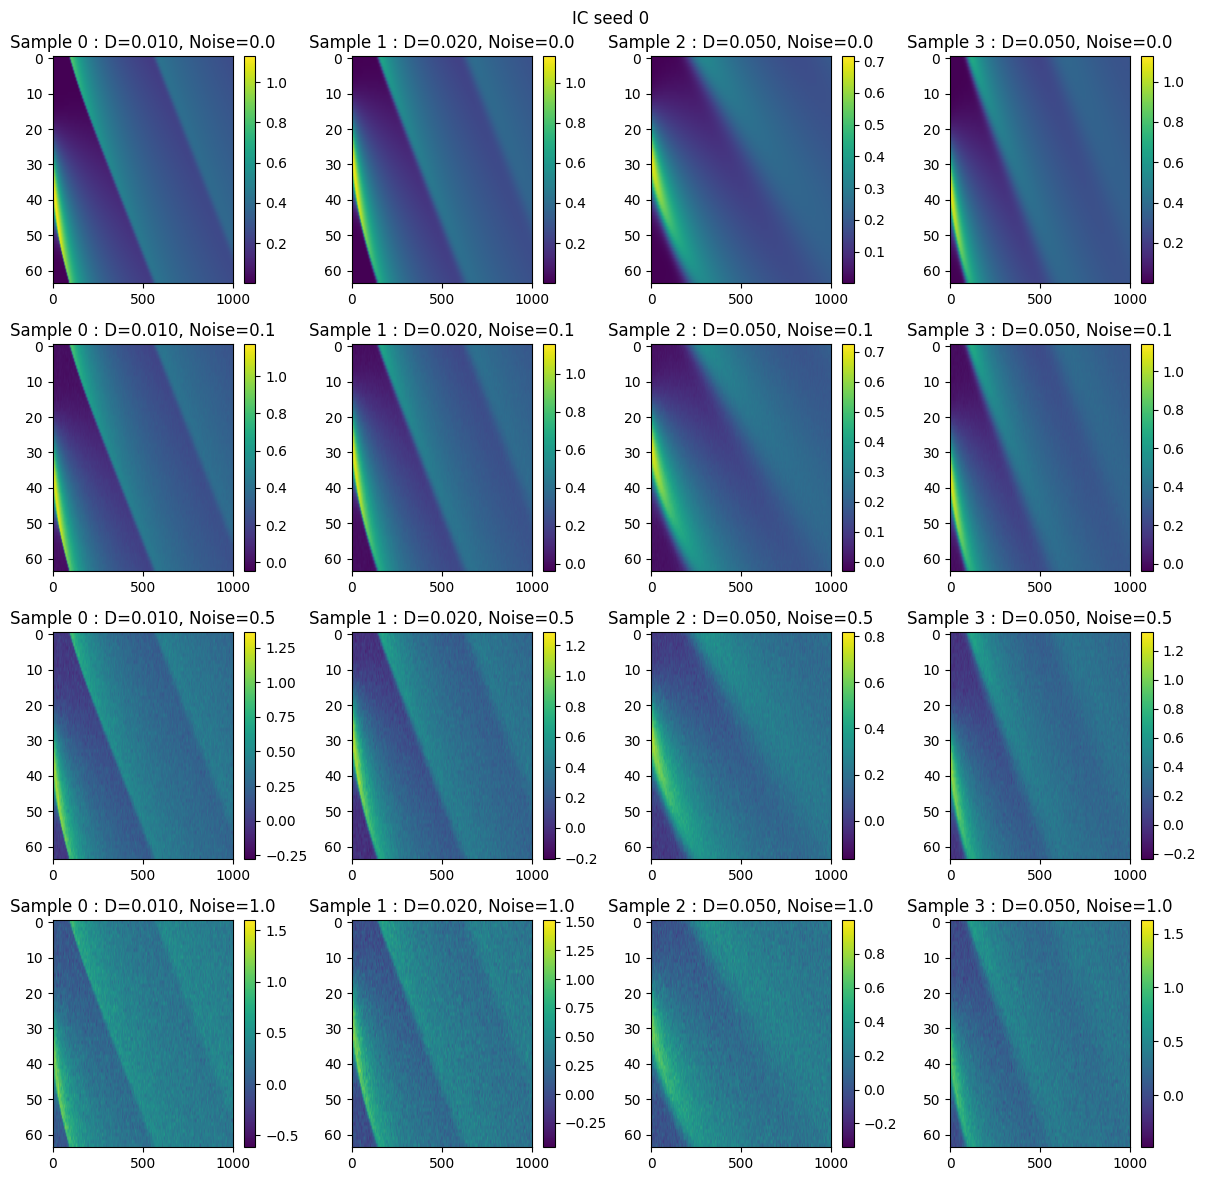

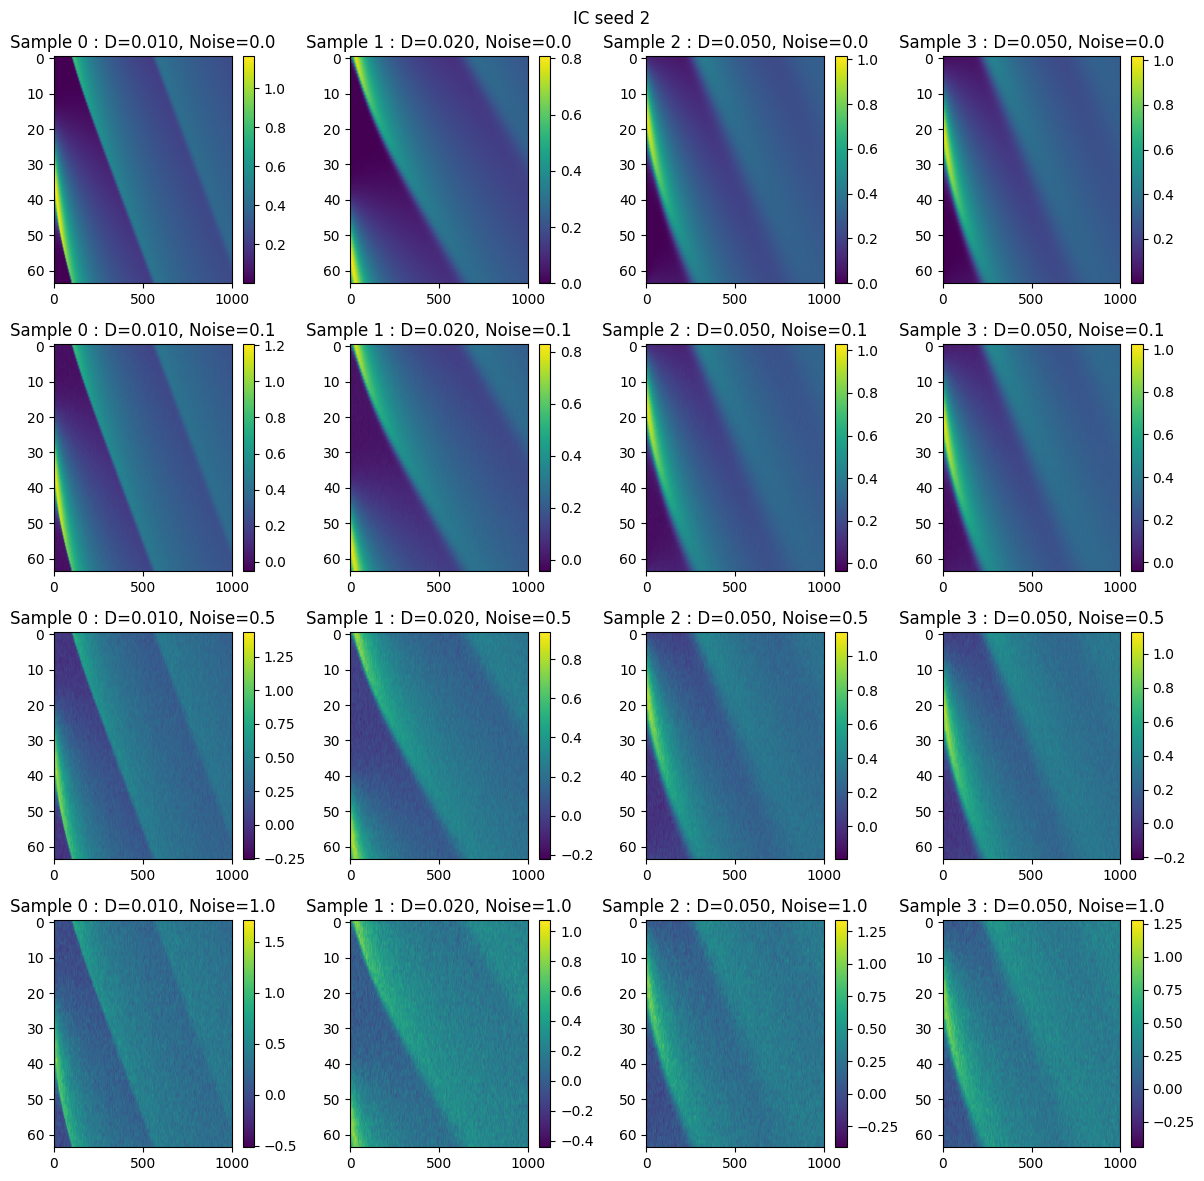

In [2]:
def dataset(noise_level, ic_seed=0):
    return ld.load_dataset(f"{DATA_DIR}/ic_seed_{ic_seed}_nl_{noise_level}.npz")


def test_mask(noise_level, rollout_steps, ic_seed=0):
    '''Boolean mask over the bench start axis: starts whose whole window is in test blocks.'''
    T = dataset(noise_level, ic_seed)["u_noisy"].shape[-1]
    train_cols, test_cols = ld.block_split(T, block_len=BLOCK_LEN)
    return ld.split_start_masks(train_cols, test_cols, T, rollout_steps)[1]

def available_noise_levels():
    return sorted(os.path.basename(f).split("_")[-1].replace(".npz", "")
                  for f in glob.glob(f"{DATA_DIR}/ic_seed_0_nl_*.npz"))

def available_ic_seeds():
    return sorted(int(os.path.basename(f).split("_")[2])
                  for f in glob.glob(f"{DATA_DIR}/ic_seed_*_nl_0.0.npz"))

NOISE_LEVELS = available_noise_levels()
print(f"Available noise levels: {NOISE_LEVELS}")
ic_seeds = available_ic_seeds()
print(f"Available IC seeds: {ic_seeds}")

n_samples = dataset(0.0, 0)["u_noisy"].shape[0]

for ic_seed in ic_seeds:
    n_noise_levels = len(NOISE_LEVELS)
    fig, axs = plt.subplots(n_noise_levels, n_samples, figsize=(n_samples * 3, n_noise_levels * 3))

    for i, noise_level in enumerate(NOISE_LEVELS):
        ds = dataset(noise_level, ic_seed)
        n_samples = ds["u_noisy"].shape[0]
        for j, sample in enumerate(ds["u_noisy"]):
            ax = axs[i, j]
            im = ax.imshow(sample, aspect="auto")
            fig.colorbar(im, ax=ax)
            ax.set_title(f"Sample {j} : D={ds['D'][j]:.3f}, Noise={noise_level}")
    plt.suptitle(f"IC seed {ic_seed}")
    plt.tight_layout()
    plt.show()



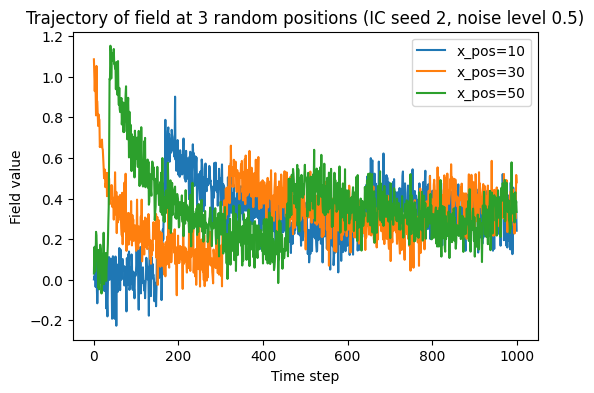

In [3]:
# plot the trajectory of the field of 3 positions 
x_coarse = [10, 30, 50]
ds = dataset(0.5, ic_seed=2)
plt.figure(figsize=(6, 4))
for x in x_coarse:
    plt.plot(ds['u_noisy'][0][x, :], label=f"x_pos={x}")
plt.xlabel("Time step")
plt.ylabel("Field value")
plt.legend()
plt.title("Trajectory of field at 3 random positions (IC seed 2, noise level 0.5)")
plt.show()


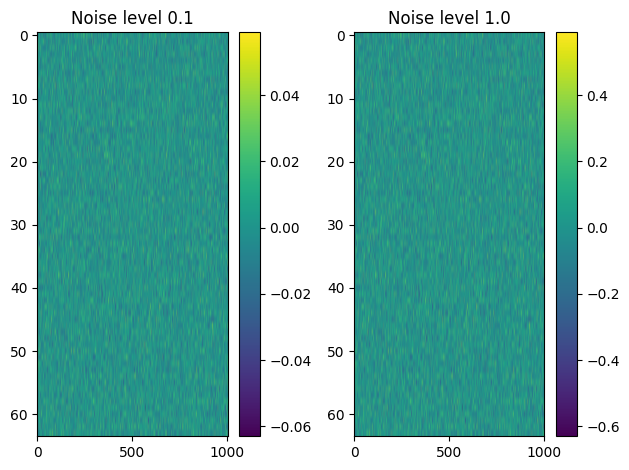

In [4]:
# Changes in noise level is so imperceptible.. Double check that different noise levels are actually different by plotting the residual between a noisy and clean field 
ic_seed = 0 
sample = 3 
ds_clean = dataset(0.0, ic_seed)  
ds_noisy_1 = dataset(0.1, ic_seed)
ds_noisy_2 = dataset(1.0, ic_seed)
resid_1 = ds_noisy_1["u_noisy"][sample] - ds_clean["u_noisy"][sample]
resid_2 = ds_noisy_2["u_noisy"][sample] - ds_clean["u_noisy"][sample]
plt.subplot(1, 2, 1)
plt.imshow(resid_1, aspect="auto")
plt.colorbar()
plt.title("Noise level 0.1")

plt.subplot(1, 2, 2)
plt.imshow(resid_2, aspect="auto")
plt.colorbar()
plt.title("Noise level 1.0")
plt.tight_layout()
plt.show()

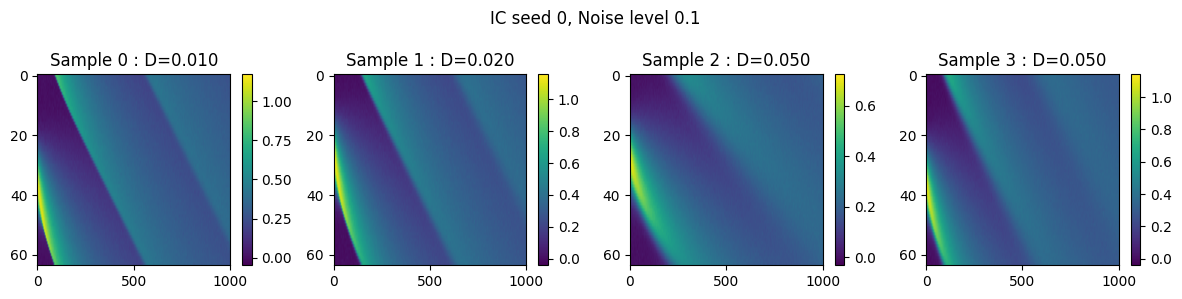

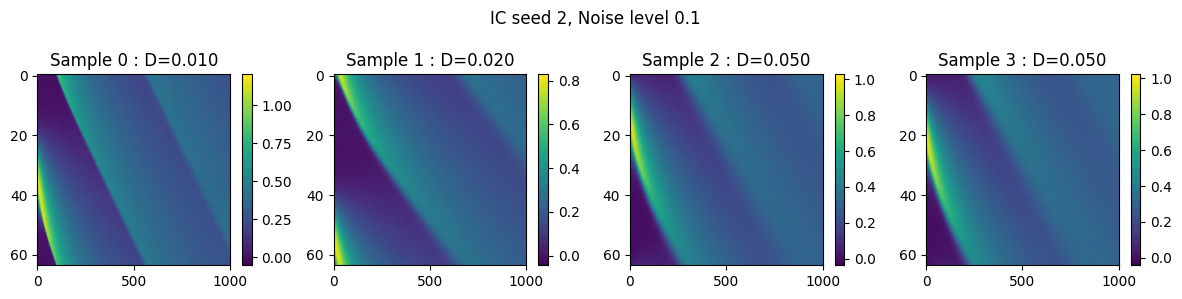

In [5]:
ic_seeds = available_ic_seeds()

for ic_seed in ic_seeds:
    fig, axs = plt.subplots(1, n_samples, figsize=(n_samples * 3, 3))

    # hardcode for plotting 
    noise_level = 0.1
    ds = dataset(noise_level, ic_seed)
    n_samples = ds["u_noisy"].shape[0]
    for j, sample in enumerate(ds["u_noisy"]):
        ax = axs[j]
        im = ax.imshow(sample, aspect="auto")
        fig.colorbar(im, ax=ax)
        ax.set_title(f"Sample {j} : D={ds['D'][j]:.3f}")
    plt.suptitle(f"IC seed {ic_seed}, Noise level {noise_level}")
    plt.tight_layout()
    plt.show()


In [6]:
# We know what the fine-grained ground truth model is, so compute the test MSE of the predictions made by the fine-grained model 
# Evaluate the residual just on the test blocks - use the same test block split as EDGAR runs 

import jax.numpy as jnp
from numpy import empty

# seeds = [0, 2]
seeds = [0]
ROLLOUT_STEPS = [1, 2, 4]
INPUT_SEQUENCE_LENGTH = 5

D_VALUES = [0.01, 0.02, 0.05, 0.05]
D_disc, D_val = jnp.array(D_VALUES[0::2]), jnp.array(D_VALUES[1::2])
print(f"D_disc: {D_disc}, D_val: {D_val}")

def gt_model_jax(data, params):
    u0 = data["x"][:, -1]
    advection = u0 * (jnp.roll(u0, -1) - jnp.roll(u0, 1))
    laplacian = jnp.roll(u0, -1) - 2.0 * u0 + jnp.roll(u0, 1)
    return u0 + advection + params["D"] * laplacian

columns = ['method', 'seed', 'noise_level', 'D', 'split', 'sample_idx', 'train_test', 'rollout_steps', 'mse_test', 'persistence_test', 'skill_test']
gt_results = pd.DataFrame(columns=columns)

for seed in seeds:    
    for noise_level in NOISE_LEVELS:
        _ds = ld.load_data(data_path=f"/home/dabin/data/burgers_simulated/ic_seed_{seed}_nl_{noise_level}.npz")
        X_disc, X_val = _ds[0], _ds[1]

        for i, X_train_test in enumerate([X_disc, X_val]):
            for rs in ROLLOUT_STEPS:
                for k, X in enumerate(X_train_test):
                    _D = D_disc if i == 0 else D_val
                    # first X is train, second X is test
                    preds, targets = evaluate(gt_model_jax, X, {"D": _D}, INPUT_SEQUENCE_LENGTH, rs)
                    mse = ld.loss_fn(preds, targets)

                    assert len(mse) == len(_D), f"Expected {len(_D)} MSE values, got {len(mse)}"
                    for j, loss in enumerate(mse):
                        sample_idx = 1 * i + 2 * j
                        gt_results = pd.concat([gt_results, pd.DataFrame([{
                            'method': 'ground_truth',
                            'seed': seed,
                            'noise_level': float(noise_level),
                            'D': _D[j],
                            'split': 'discover' if i == 0 else 'validate',
                            'sample_idx': sample_idx,
                            'train_test': 'train' if k == 0 else 'test',
                            'rollout_steps': rs,
                            'mse_test': mse[j],
                            'persistence_test': np.nan, 'skill_test' : np.nan,
                        }])], ignore_index=True)

gt_results.head()

D_disc: [0.01 0.05], D_val: [0.02 0.05]


,method,seed,noise_level,D,split,sample_idx,train_test,rollout_steps,mse_test,persistence_test,skill_test
0,ground_truth,0,0.0,0.01,discover,0,train,1,0.0024741506,NaN,NaN
1,ground_truth,0,0.0,0.05,discover,2,train,1,0.00011614535,NaN,NaN
2,ground_truth,0,0.0,0.01,discover,0,test,1,0.00038909077,NaN,NaN
3,ground_truth,0,0.0,0.05,discover,2,test,1,1.8300192e-05,NaN,NaN
4,ground_truth,0,0.0,0.01,discover,0,train,2,0.004817899,NaN,NaN


In [9]:
gt_results[(gt_results['rollout_steps'] == 2) & (gt_results['noise_level'] == 0.1) * (gt_results['split'] == 'discover') & (gt_results['sample_idx'] == 2)]

,method,seed,noise_level,D,split,sample_idx,train_test,rollout_steps,mse_test,persistence_test,skill_test
29,ground_truth,0,0.1,0.05,discover,2,train,2,0.0004550834,NaN,NaN
31,ground_truth,0,0.1,0.05,discover,2,test,2,0.00021406746,NaN,NaN


## 1. Bench results (SINDy strong/weak, STENCIL-NET)

One row per (method, noise, horizon, sample). `mse_test` / `skill_test` are the **noisy-scored**
re-scoring written by `rescore_noisy.py`; `mse_test_cleanscored` is the original clean-target
number, kept only for provenance.

In [10]:
def load_bench(path=f"{BENCH}/results/rescore_noisy.json"):
    cells = json.load(open(path))["runs"]
    rows = []
    for c in cells:
        clean = {h["rollout_steps"]: h for h in c["horizons_clean_scored"]}
        for h in c["horizons_noisy_scored"]:
            r = h["rollout_steps"]
            rows.append(
                dict(
                    method=c["method"], noise_level=c["noise_level"], rollout_steps=r,
                    sample_idx=c["sample_idx"], D=c["D"],
                    mse_test=h["forecast_mse_test"],
                    persistence_test=h["persistence_mse_test"],
                    skill_test=h["skill_test"], stable=h["stable"],
                    mse_test_cleanscored=clean[r]["forecast_mse_test"],
                )
            )
    df = pd.DataFrame(rows)
    df["split"] = np.where(df.sample_idx.isin(DISCOVER_IDX), "discover", "validate")
    return df.sort_values(["method", "noise_level", "rollout_steps", "sample_idx"])


bench = load_bench()
bench = bench[bench["noise_level"].isin([float(x) for x in NOISE_LEVELS])]
bench.head(n=20)
# bench

,method,noise_level,rollout_steps,sample_idx,D,mse_test,persistence_test,skill_test,stable,mse_test_cleanscored,split
0,sindy_strong,0.0,1,0,0.01,3.564770e-06,1.326185e-05,0.731201,True,3.564770e-06,discover
48,sindy_strong,0.0,1,0,0.01,3.804229e-06,1.433109e-05,0.734547,True,3.804229e-06,discover
3,sindy_strong,0.0,1,1,0.02,2.546369e-07,6.277524e-06,0.959437,True,2.546369e-07,validate
51,sindy_strong,0.0,1,1,0.02,2.097878e-08,2.037564e-06,0.989704,True,2.097878e-08,validate
6,sindy_strong,0.0,1,2,0.05,6.633715e-11,5.434686e-07,0.999878,True,6.633715e-11,discover
54,sindy_strong,0.0,1,2,0.05,7.398320e-10,1.519618e-06,0.999513,True,7.398320e-10,discover
9,sindy_strong,0.0,1,3,0.05,2.951644e-09,1.999386e-06,0.998524,True,2.951644e-09,validate
57,sindy_strong,0.0,1,3,0.05,5.993116e-10,1.529682e-06,0.999608,True,5.993116e-10,validate
1,sindy_strong,0.0,2,0,0.01,8.871894e-06,3.300796e-05,0.731220,True,8.871894e-06,discover
49,sindy_strong,0.0,2,0,0.01,9.450015e-06,3.559342e-05,0.734501,True,9.450015e-06,discover


## 2. EDGAR results

Nine GCP runs: 3 noise levels x 3 rollout horizons, named `burgers-nl{0,001,01}-r{1,2,4}`.
Losses come straight out of `population.jsonl` — `sample_losses` is the per-sample
**discover-test** MSE and is what `program_losses.discover.final` averages (the parameter
penalty is 1e-9 * n_params, negligible at this loss scale).

Note `program.params` on disk is the *last fit performed*, which for validated programs is the
**validate**-split fit — so do not use it to reproduce discover predictions. `edgar_predict`
below refits instead.

In [11]:
date_patterns = ("2026-07-31", "2026-08-03")
def edgar_runs(runs_dir=RUNS_DIR, pattern=["burgers-nl*-r*"]):
    '''Every fetched EDGAR run dir with a population, newest timestamp per run name.'''
    out = {}
    spec_paths = []
    for date_pattern in date_patterns:
        for p in pattern:
            search_pattern = os.path.join(
                runs_dir,
                p,
                date_pattern,
                "*",
                "task_spec.yaml",
            )
            spec_paths.extend(glob.glob(search_pattern))

    for spec_path in sorted(spec_paths):
        d = os.path.dirname(spec_path)
        pop_path = f"{d}/population.jsonl"
        if not os.path.exists(pop_path):
            continue
        spec = yaml.safe_load(open(spec_path))
        n = sum(1 for _ in open(pop_path))
        name = d.split("/")[-3]
        # the data path in task_spec is the VM-side one; map it back to the local file
        local_data = os.path.join(DATA_DIR, os.path.basename(spec["io"]["data_path"]))
        rec = dict(
            run=name, run_dir=d, n_programs=n, spec=spec, data_path=local_data,
            noise_level=float(ld.load_dataset(local_data)["noise_level"]),
            rollout_steps=spec["evaluate"]["rollout_steps"],
            input_sequence_length=spec["evaluate"]["input_sequence_length"],
        )
        # keep the run with the most programs (aborted relaunches leave stubs behind)
        if name not in out or n > out[name]["n_programs"]:
            out[name] = rec
    return out


# only select runs with noise level in NOISE_LEVELS 
RUNS = edgar_runs(pattern = ["burgers-nl0-r*", "burgers-nl01-r*", "burgers-nl05-r*", "burgers-nl1-r*"])
pd.DataFrame(
    [{k: v[k] for k in ("run", "n_programs", "noise_level", "rollout_steps")} for v in RUNS.values()]
)

,run,n_programs,noise_level,rollout_steps
0,burgers-nl0-r1,62,0.0,1
1,burgers-nl0-r2,62,0.0,2
2,burgers-nl0-r4,62,0.0,4
3,burgers-nl01-r1,62,0.1,1
4,burgers-nl01-r2,62,0.1,2
5,burgers-nl01-r4,62,0.1,4
6,burgers-nl05-r1,62,0.5,1
7,burgers-nl05-r2,62,0.5,2
8,burgers-nl05-r4,62,0.5,4
9,burgers-nl1-r1,62,1.0,1


In [12]:
def edgar_programs(run):
    '''All programs of one run as a DataFrame, best (lowest discover-test loss) first.'''
    rec = RUNS[run] if isinstance(run, str) else run
    rows = []
    for line in open(f"{rec['run_dir']}/population.jsonl"):
        p = json.loads(line)
        disc = p["program_losses"]["discover"]["final"]
        val = p["program_losses"]["validate"]["final"]
        sl = p.get("sample_losses")
        rows.append(
            dict(
                run=rec["run"], noise_level=rec["noise_level"],
                rollout_steps=rec["rollout_steps"], idx=p["idx"], name=p["name"],
                generation=p["birth"]["generation"], island=p["birth"]["island"],
                status=p["status"], n_params=p["n_params"],
                discover_test=disc if isinstance(disc, float) else np.nan,
                validate_test=val if isinstance(val, float) else np.nan,
                sample_losses=sl,
            )
        )
    return pd.DataFrame(rows).sort_values("discover_test", na_position="last")


def edgar_best(runs=RUNS, per_sample=True):
    '''Best program per run, optionally exploded to one row per discover sample.'''
    rows = []
    for rec in runs.values():
        top = edgar_programs(rec).iloc[0]
        if not per_sample or top.sample_losses is None:
            rows.append(top.drop("sample_losses").to_dict())
            continue
        D = ld.load_dataset(rec["data_path"])["D"]
        for k, (s, mse) in enumerate(zip(DISCOVER_IDX, top.sample_losses)):
            rows.append({**top.drop("sample_losses").to_dict(),
                         "sample_idx": int(s), "D": float(D[s]), "mse_test": mse})
    return pd.DataFrame(rows).sort_values(["noise_level", "rollout_steps"])


edgar = edgar_best()
edgar[["run", "idx", "name", "n_params", "noise_level", "rollout_steps", "sample_idx", "D", "mse_test"]]

,run,idx,name,n_params,noise_level,rollout_steps,sample_idx,D,mse_test
0,burgers-nl0-r1,32,Spatiotemporal Dynamics with Viscous and Accel...,6.0,0.0,1,0,0.01,2.005597e-07
1,burgers-nl0-r1,32,Spatiotemporal Dynamics with Viscous and Accel...,6.0,0.0,1,2,0.05,8.647275e-09
2,burgers-nl0-r2,54,Amplitude-Damped Gradient-Activated Advection-...,6.0,0.0,2,0,0.01,1.216255e-06
3,burgers-nl0-r2,54,Amplitude-Damped Gradient-Activated Advection-...,6.0,0.0,2,2,0.05,3.321512e-07
4,burgers-nl0-r4,52,Nonlinear Advection-Diffusion-Dispersion Model...,6.0,0.0,4,0,0.01,8.725251e-06
5,burgers-nl0-r4,52,Nonlinear Advection-Diffusion-Dispersion Model...,6.0,0.0,4,2,0.05,4.197212e-07
6,burgers-nl01-r1,47,Non-linear Advection with Advection-Diffusion ...,4.0,0.1,1,0,0.01,3.229527e-04
7,burgers-nl01-r1,47,Non-linear Advection with Advection-Diffusion ...,4.0,0.1,1,2,0.05,1.161103e-04
8,burgers-nl01-r2,40,Advection-Diffusion-Decay-Hyperdiffusion-Nonli...,5.0,0.1,2,0,0.01,3.238614e-04
9,burgers-nl01-r2,40,Advection-Diffusion-Decay-Hyperdiffusion-Nonli...,5.0,0.1,2,2,0.05,1.151018e-04


### EDGAR persistence floor

Computed on EDGAR's own tensors (same blocks, same start set), so `skill` is internally
consistent with its MSE. `do_nothing` just returns the most recent lag.

In [13]:
def edgar_data(run, split="discover"):
    '''(X_train, X_test) for one run's split, plus the evaluate fn bound to its config.'''
    rec = RUNS[run] if isinstance(run, str) else run
    (dtr, dte), (vtr, vte), _ = ld.load_data(data_path=rec["data_path"], **rec["spec"]["project_params"])
    ev = rec["spec"]["evaluate"]
    evaluate_fn = partial(evaluate, input_sequence_length=ev["input_sequence_length"],
                          rollout_steps=ev["rollout_steps"])
    return ((dtr, dte) if split == "discover" else (vtr, vte)), evaluate_fn


def edgar_persistence(run, split="discover"):
    (_, X_test), evaluate_fn = edgar_data(run, split)
    preds, targets = evaluate_fn(lambda data, params: data["x"][:, -1], X_test, {})
    return np.asarray(ld.loss_fn(preds, targets))


pers = {r: edgar_persistence(r) for r in RUNS}
edgar["persistence_test"] = [
    pers[row.run][list(DISCOVER_IDX).index(row.sample_idx)] for row in edgar.itertuples()
]
edgar["skill_test"] = 1 - edgar.mse_test / edgar.persistence_test
edgar["method"] = "edgar"
edgar["split"] = "discover"
edgar[["run", "sample_idx", "D", "mse_test", "persistence_test", "skill_test"]]

,run,sample_idx,D,mse_test,persistence_test,skill_test
0,burgers-nl0-r1,0,0.01,2.005597e-07,1.298933e-05,0.984560
1,burgers-nl0-r1,2,0.05,8.647275e-09,5.317265e-07,0.983737
2,burgers-nl0-r2,0,0.01,1.216255e-06,3.228251e-05,0.962325
3,burgers-nl0-r2,2,0.05,3.321512e-07,1.328657e-06,0.750010
4,burgers-nl0-r4,0,0.01,8.725251e-06,9.518925e-05,0.908338
5,burgers-nl0-r4,2,0.05,4.197212e-07,3.982875e-06,0.894619
6,burgers-nl01-r1,0,0.01,3.229527e-04,4.703437e-04,0.313369
7,burgers-nl01-r1,2,0.05,1.161103e-04,1.802675e-04,0.355900
8,burgers-nl01-r2,0,0.01,3.238614e-04,4.881725e-04,0.336584
9,burgers-nl01-r2,2,0.05,1.151018e-04,1.818847e-04,0.367172


## 3. Combined comparison

Discover samples only (D = 0.005, 0.010), averaged over the two of them.

In [44]:
all_results[all_results.split == "discover"]

,method,noise_level,rollout_steps,sample_idx,D,split,mse_test,persistence_test,skill_test
0,sindy_strong,0.0,1,0,0.01,discover,0.000004,0.000013,0.731201
1,sindy_strong,0.0,1,0,0.01,discover,0.000004,0.000014,0.734547
4,sindy_strong,0.0,1,2,0.05,discover,0.0,0.000001,0.999878
5,sindy_strong,0.0,1,2,0.05,discover,0.0,0.000002,0.999513
8,sindy_strong,0.0,2,0,0.01,discover,0.000009,0.000033,0.73122
...,...,...,...,...,...,...,...,...,...
301,ground_truth,1.0,1,2,0.05,discover,0.017313039,NaN,NaN
302,ground_truth,1.0,2,0,0.01,discover,0.056637213,NaN,NaN
303,ground_truth,1.0,2,2,0.05,discover,0.017339732,NaN,NaN
304,ground_truth,1.0,4,0,0.01,discover,0.07822218,NaN,NaN


In [ ]:
COLS = ["method", "noise_level", "rollout_steps", "sample_idx", "D", "split",
        "mse_test", "persistence_test", "skill_test"]
all_results = pd.concat([bench[COLS], edgar[COLS], gt_results[gt_results['train_test'] == 'test'][COLS]], ignore_index=True)

# disc = all_results[(all_results.split == "discover")]
disc = all_results[(all_results.split == "discover") & (all_results.sample_idx == 2)]
mse_table = disc.pivot_table(index=["noise_level", "rollout_steps"], columns="method",
                             values="mse_test", aggfunc="mean")
skill_table = disc.pivot_table(index=["noise_level", "rollout_steps"], columns="method",
                               values="skill_test", aggfunc="mean")
print("forecast MSE (discover-test, noisy targets, mean over the 2 discover samples)")
display(mse_table)
print("\nskill = 1 - mse/persistence  (each method against its own persistence floor)")
display(skill_table)

forecast MSE (discover-test, noisy targets, mean over the 2 discover samples)


method                        edgar ground_truth sindy_strong  sindy_weak  \
noise_level rollout_steps                                                   
0.0         1                   0.0     0.000018          0.0         0.0   
            2                   0.0     0.000045          0.0         0.0   
            4                   0.0     0.000131          0.0         0.0   
0.1         1              0.000116      0.00019     0.000244    0.000199   
            2              0.000115     0.000214     0.000243    0.000188   
            4              0.000112     0.000296     0.000242    0.000176   
0.5         1               0.00287     0.004312     0.006114    0.005807   
            2              0.002827     0.004296     0.006123    0.005687   
            4              0.002704     0.004316     0.006103    0.005462   
1.0         1              0.025752     0.017313     0.024447    0.024294   
            2              0.010815      0.01734     0.024473    0.024353   
            4              0.010526     0.017442     0.024378  500.014518   

method                    stencilnet  
noise_level rollout_steps             
0.0         1                    0.0  
            2                    0.0  
            4                    0.0  
0.1         1               0.000177  
            2               0.000175  
            4               0.000169  
0.5         1               0.004479  
            2               0.004482  
            4               0.004476  
1.0         1                0.03868  
            2                  0.018  
            4               0.017943


skill = 1 - mse/persistence  (each method against its own persistence floor)


method                        edgar sindy_strong    sindy_weak stencilnet
noise_level rollout_steps                                                
0.0         1              0.983737     0.999696      0.999682   0.994183
            2               0.75001       0.9997      0.999685   0.999339
            4              0.894619     0.999706       0.99969   0.999069
0.1         1                0.3559     0.009669      0.187294   0.017436
            2              0.367172     0.018094      0.236304   0.036937
            4              0.391655       0.0415      0.299836    0.08358
0.5         1              0.361417     0.002109      0.047118   0.003935
            2              0.373747     0.003177      0.067064   0.007409
            4              0.401116     0.005529      0.099653   0.008805
1.0         1             -0.432797     0.002582      0.001578  -1.150887
            2              0.400986     0.003886     -0.003004   0.003115
            4              0.416861     0.006419 -27700.156179   0.005907

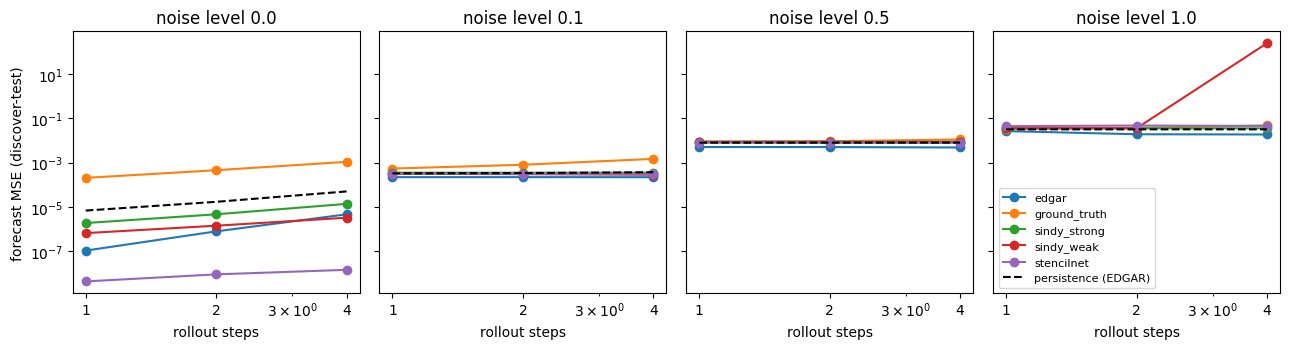

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), sharey=True)
methods = list(mse_table.columns)
for ax, nl in zip(axes, sorted(disc.noise_level.unique())):
    sub = disc[disc.noise_level == nl]
    for m in methods:
        g = sub[sub.method == m].groupby("rollout_steps")
        ax.plot(list(g.groups), g.mse_test.mean(), "o-", label=m)
    ax.plot(sorted(sub.rollout_steps.unique()),
            sub[sub.method == "edgar"].groupby("rollout_steps").persistence_test.mean(),
            "k--", label="persistence (EDGAR)")
    ax.set(yscale="log", xscale="log", xticks=[1, 2, 4], title=f"noise level {nl}",
           xlabel="rollout steps")
    ax.set_xticklabels([1, 2, 4])
axes[0].set_ylabel("forecast MSE (discover-test)")
axes[-1].legend(fontsize=8)
fig.tight_layout()

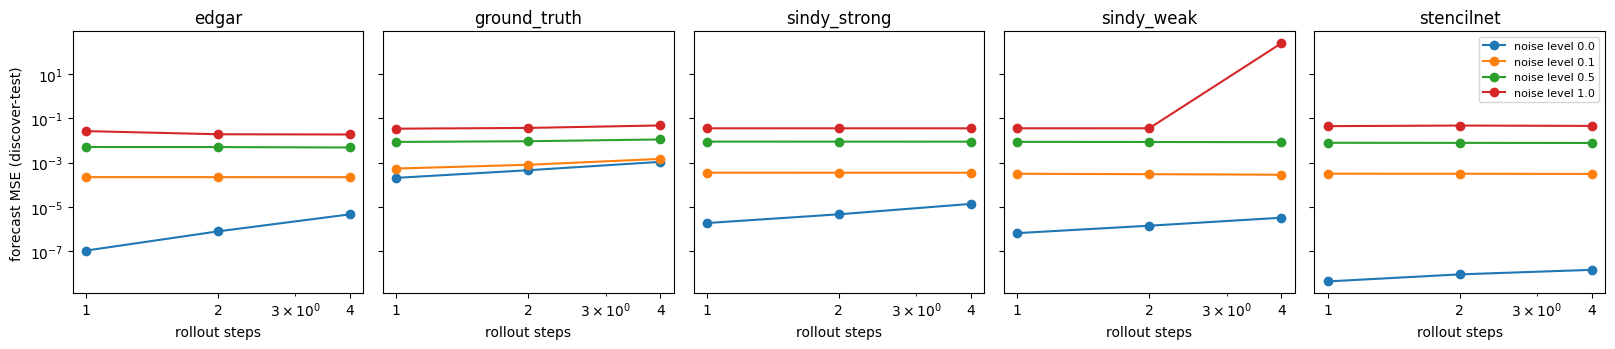

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(16.25, 3.6), sharey=True)
methods = list(mse_table.columns)
for ax, method in zip(axes, methods):
    sub = disc[disc.method == method]
    for nl in sorted(disc.noise_level.unique()):
        g = sub[sub.noise_level == nl].groupby("rollout_steps")
        ax.plot(list(g.groups), g.mse_test.mean(), "o-", label=f"noise level {nl}")
    ax.set(yscale="log", xscale="log", xticks=[1, 2, 4], title=f"{method}",
           xlabel="rollout steps")
    ax.set_xticklabels([1, 2, 4])
axes[0].set_ylabel("forecast MSE (discover-test)")
axes[-1].legend(fontsize=8)
fig.tight_layout()

## 4. Pulling predictions

Each `*_predict` returns `(preds, targets)`. The bench methods are on their native grid
`(n_starts, h, n_sensors)` with `n_starts = T - h`; EDGAR is on
`(n_samples, n_blocks, n_starts, h, n_sensors)`. `to_canvas` flattens either onto a
`(n_sensors, T)` field of the `h`-step-ahead prediction, NaN where nothing was predicted, so
they can be plotted against each other.

In [43]:
all_results[(all_results['method'] == 'ground_truth') & (all_results['rollout_steps'] == 2) & (all_results['noise_level'] == 0.1) & (all_results['split'] == 'discover') & (all_results['sample_idx'] == 2)]

,method,noise_level,rollout_steps,sample_idx,D,split,mse_test,persistence_test,skill_test
279,ground_truth,0.1,2,2,0.05,discover,0.00021406746,NaN,NaN


In [21]:
import torch
import torch.nn as nn

from network import MLPConv    # bench/stencilnet/stencilnet_src/network.py

try:
    from runner import make_rhs    # bench/sindy/runner.py -- imports pysindy at module level
except ModuleNotFoundError as e:
    make_rhs = None
    print(f"sindy_predict unavailable ({e}); restart the kernel with --with pysindy")


def sindy_predict(noise_level, sample_idx, rollout_steps, variant="weak", ic_seed=0):
    ds = dataset(noise_level, ic_seed)
    u_obs = ds["u_noisy"][sample_idx]
    res = json.load(open(f"{BENCH}/sindy/results/sindy_{variant}_ic{ic_seed}_nl{noise_level}_s{sample_idx}.json"))
    dx = float(ds["x_coarse"][1] - ds["x_coarse"][0])
    N = make_rhs(res["feature_names"], res["coefficients"], dx)
    return ld.teacher_forced_forecast(lambda state, t: N(state), u_obs, ds["dtc"], rollout_steps)


def stencilnet_predict(noise_level, sample_idx, rollout_steps, ic_seed=0, device="cpu"):
    ds = dataset(noise_level, ic_seed)
    u_obs = ds["u_noisy"][sample_idx]
    ckpt = torch.load(
        f"{DATA_DIR}/stencilnet_weights/ic{ic_seed}_nl{noise_level}_r{rollout_steps}_s{sample_idx}.pt",
        map_location="cpu", weights_only=False,
    )
    net = MLPConv(ckpt["sizes"], seed=ckpt["seed"], fs=ckpt["fs"], activation=nn.ELU()).to(device)
    net.load_state_dict(ckpt["state_dict"])
    net.noise = None      # inference: the latent noise field is a training-time construct
    net.eval()

    def rhs(state, t):
        with torch.no_grad():
            return net(torch.tensor(state, dtype=torch.float, device=device)).cpu().numpy()

    return ld.teacher_forced_forecast(rhs, u_obs, ds["dtc"], rollout_steps)

In [49]:
variant = 'weak'
noise_level = "0.0"
sample_idx = 2
ic_seed = 0
res = json.load(open(f"{BENCH}/sindy/results/sindy_{variant}_ic{ic_seed}_nl{noise_level}_s{sample_idx}.json"))
print(res.keys())
for name, value in zip(res["feature_names"], res["coefficients"]):
    print(res["equation"], res["n_terms"])
    # if value != 0.0:        
    #     print(f"{name}: {value:.8f}")

dict_keys(['method', 'data_path', 'ic_seed', 'sample_idx', 'D', 'noise_level', 'threshold', 'block_len', 'n_x', 'equation', 'feature_names', 'coefficients', 'n_terms', 'coef_u_xx', 'true_u_xx', 'coef_uu_x', 'true_uu_x', 'rel_err_u_xx', 'rel_err_uu_x', 'horizons'])
0.004 u^2 + -0.012 u_1 + 0.048 u_11 + -0.933 uu_1 + -0.119 u^2u_1 + 0.010 uu_11 6
0.004 u^2 + -0.012 u_1 + 0.048 u_11 + -0.933 uu_1 + -0.119 u^2u_1 + 0.010 uu_11 6
0.004 u^2 + -0.012 u_1 + 0.048 u_11 + -0.933 uu_1 + -0.119 u^2u_1 + 0.010 uu_11 6
0.004 u^2 + -0.012 u_1 + 0.048 u_11 + -0.933 uu_1 + -0.119 u^2u_1 + 0.010 uu_11 6
0.004 u^2 + -0.012 u_1 + 0.048 u_11 + -0.933 uu_1 + -0.119 u^2u_1 + 0.010 uu_11 6
0.004 u^2 + -0.012 u_1 + 0.048 u_11 + -0.933 uu_1 + -0.119 u^2u_1 + 0.010 uu_11 6
0.004 u^2 + -0.012 u_1 + 0.048 u_11 + -0.933 uu_1 + -0.119 u^2u_1 + 0.010 uu_11 6
0.004 u^2 + -0.012 u_1 + 0.048 u_11 + -0.933 uu_1 + -0.119 u^2u_1 + 0.010 uu_11 6
0.004 u^2 + -0.012 u_1 + 0.048 u_11 + -0.933 uu_1 + -0.119 u^2u_1 + 0.010 uu_11

In [50]:
from edgar.evolution.population import Population
from edgar.scoring.scoring import _get_params, _optimize

def edgar_predict(run, program_idx=None, split="discover"):
    '''Refit a program's params on `split`-train and roll it out on `split`-test.

    Refits rather than reusing the saved `program.params`, which for validated programs
    holds the validate-split fit. Reproduces `sample_losses` to float32 for the discover split.
    '''
    rec = RUNS[run] if isinstance(run, str) else run
    prog = Population.load(f"{rec['run_dir']}/population.jsonl")[
        int(program_idx) if program_idx is not None else int(edgar_programs(rec).iloc[0].idx)
    ]
    (X_train, X_test), evaluate_fn = edgar_data(rec, split)
    model_fn = prog.compile_model()
    p0 = _get_params(prog.compile_param_est(), prog.default_params, X_train)
    params = _optimize(model_fn, ld.loss_fn, evaluate_fn, p0, X_train,
                       rec["spec"]["scoring"]["gradient_descent"])
    preds, targets = evaluate_fn(model_fn, X_test, params)
    return np.asarray(preds), np.asarray(targets), params, prog


preds_e, targets_e, params_e, prog_e = edgar_predict("burgers-nl0-r1")
print(prog_e.name)
print("per-sample MSE", ld.loss_fn(preds_e, targets_e), " (matches sample_losses)")
print("preds", preds_e.shape, " params", {k: np.asarray(v).round(4).tolist() for k, v in params_e.items()})

Spatiotemporal Dynamics with Viscous and Acceleration Damping
per-sample MSE [2.0055924e-07 8.6399025e-13]  (matches sample_losses)
preds (2, 2, 195, 1, 64)  params {'acceleration_damping': [0.3758000135421753, 0.4528999924659729], 'bias': [0.0003000000142492354, 0.0], 'coupling_left': [0.0340999998152256, 0.0010999999940395355], 'coupling_right': [-0.02500000037252903, 0.0005000000237487257], 'reaction_rate': [0.009999999776482582, 0.0015999999595806003], 'viscous_damping': [0.7038999795913696, 0.9940000176429749]}


In [58]:
# print(prog_e.model_code)
for key, value in params_e.items():
    print(f"{key}: {value[0]:.8f}")

acceleration_damping: 0.37577757
bias: 0.00026488
coupling_left: 0.03413179
coupling_right: -0.02495866
reaction_rate: 0.01000800
viscous_damping: 0.70390230


In [39]:
def to_canvas(preds, n_times, rollout_steps, kind, block_len=BLOCK_LEN,
              input_sequence_length=5, sample=0):
    '''h-step-ahead predictions laid out on a (n_sensors, n_times) field, NaN = not predicted.

    kind='bench'  : preds (n_starts, h, n_sensors), start i predicts columns i+1 .. i+h
    kind='edgar'  : preds (n_samples, n_blocks, n_starts, h, n_sensors) over TEST blocks only
    '''
    h = int(rollout_steps)
    if kind == "bench":
        n_starts, _, n_sensors = preds.shape
        canvas = np.full((n_sensors, n_times), np.nan)
        canvas[:, np.arange(n_starts) + h] = preds[:, h - 1, :].T
        return canvas
    p = preds[sample]                                   # (n_blocks, n_starts, h, n_sensors)
    n_blocks, n_starts, _, n_sensors = p.shape
    canvas = np.full((n_sensors, n_times), np.nan)
    _, test_blocks = ld.train_test_blocks(n_times, block_len)
    starts = np.arange(input_sequence_length - 1, block_len - h)
    for b, block in zip(test_blocks, p):
        canvas[:, b * block_len + starts + h] = block[:, h - 1, :].T
    return canvas

input 7 output 64
input 64 output 64
input 64 output 64
input 64 output 1


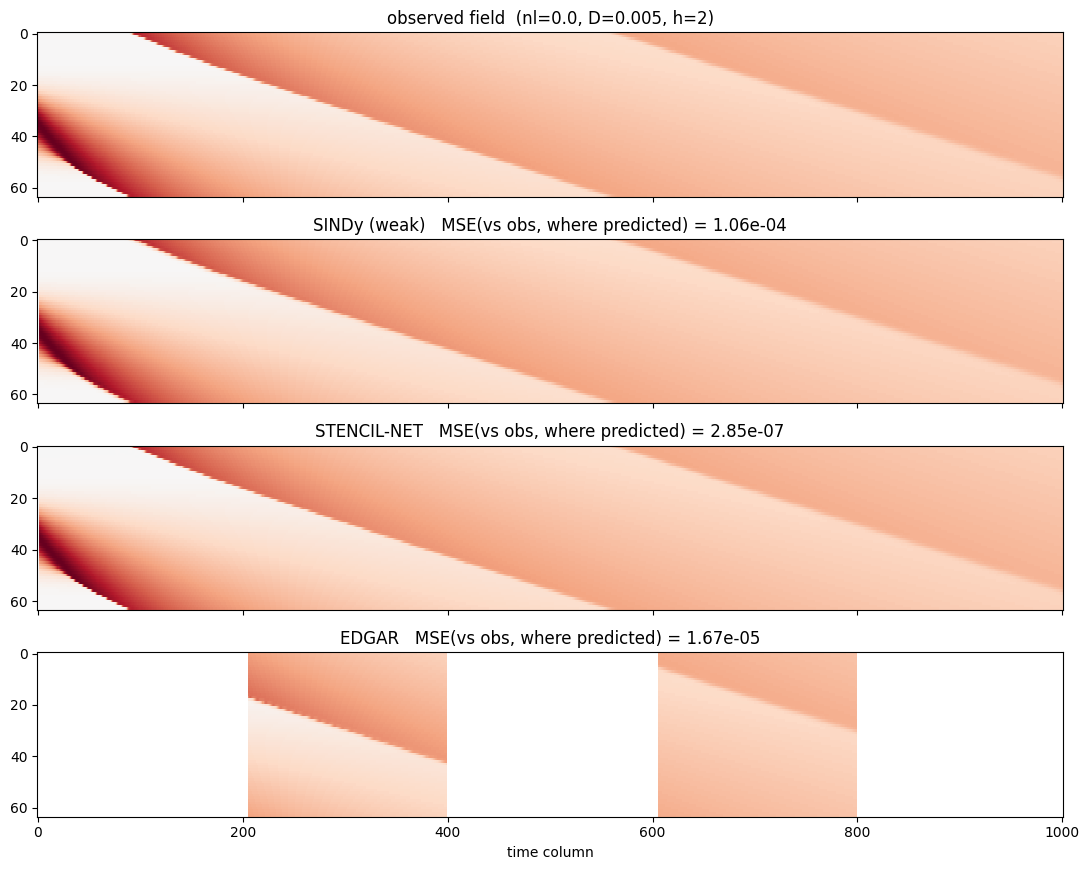

In [11]:
# one cell of the grid, all three methods + truth, as h-step-ahead fields
NL, H, SAMPLE = 0.0, 2, 0            # sample 0 -> D = 0.005
ds = dataset(NL)
truth = ds["u_noisy"][SAMPLE]
T = truth.shape[1]

canvases = {
    "SINDy (weak)": to_canvas(sindy_predict(NL, SAMPLE, H)[0], T, H, "bench"),
    "STENCIL-NET": to_canvas(stencilnet_predict(NL, SAMPLE, H)[0], T, H, "bench"),
    "EDGAR": to_canvas(edgar_predict(f"burgers-nl0-r{H}")[0], T, H, "edgar", sample=SAMPLE),
}

fig, axes = plt.subplots(len(canvases) + 1, 1, figsize=(11, 2.2 * (len(canvases) + 1)), sharex=True)
lim = np.nanmax(np.abs(truth))
kw = dict(aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim, interpolation="nearest")
axes[0].imshow(truth, **kw)
axes[0].set_title(f"observed field  (nl={NL}, D={ds['D'][SAMPLE]}, h={H})")
for ax, (name, c) in zip(axes[1:], canvases.items()):
    ax.imshow(c, **kw)
    ax.set_title(f"{name}   MSE(vs obs, where predicted) = {np.nanmean((c - truth) ** 2):.2e}")
axes[-1].set_xlabel("time column")
fig.tight_layout()

Text(0.5, 0, 'time column')

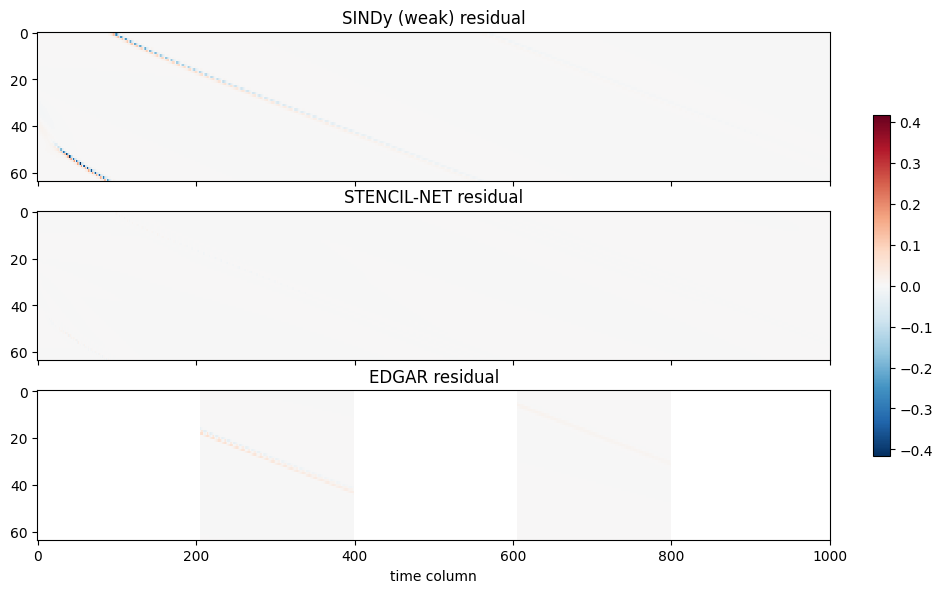

In [12]:
# residual fields, same cell — where each method actually loses
fig, axes = plt.subplots(len(canvases), 1, figsize=(11, 2.2 * len(canvases)), sharex=True)
rlim = max(np.nanmax(np.abs(c - truth)) for c in canvases.values())
for ax, (name, c) in zip(axes, canvases.items()):
    im = ax.imshow(c - truth, aspect="auto", cmap="RdBu_r", vmin=-rlim, vmax=rlim,
                   interpolation="nearest")
    ax.set_title(f"{name} residual")
fig.colorbar(im, ax=axes, fraction=0.02)
axes[-1].set_xlabel("time column")

## Scratch

`edgar_programs("burgers-nl0-r2")` for the full population of a run,
`all_results` for the tidy frame, `bench` / `edgar` for the per-method ones.
`edgar_predict(run, program_idx=...)` rolls out any program, not just the best.